# Aula 1: Passeio quânticos

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.primitives import Sampler
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

In [2]:
from qiskit import __version__
print(__version__)

1.2.4


In [3]:
from qiskit.circuit.library import MCMT

# Formalismo matemático

O operador de evolução para uma etapa é $U=S(C \otimes I_p)$, onde:
1. Operador de moeda $(C)$: Usaremos o portão Hadamard $(H)$ no qubit da moeda para criar superposição.
\begin{equation}
C = H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}
\end{equation}

2. Operador de Deslocamento $(S)$: Move ao caminhante dependendo do estado da moeda.

- Se a moeda for igual a $|0\rangle$ $\rightarrow$ Incrementa a posição em (+1).

- Se a moeda for igual a $|1\rangle$ $\rightarrow$ Decrementa a posição em (−1).


## Circuito

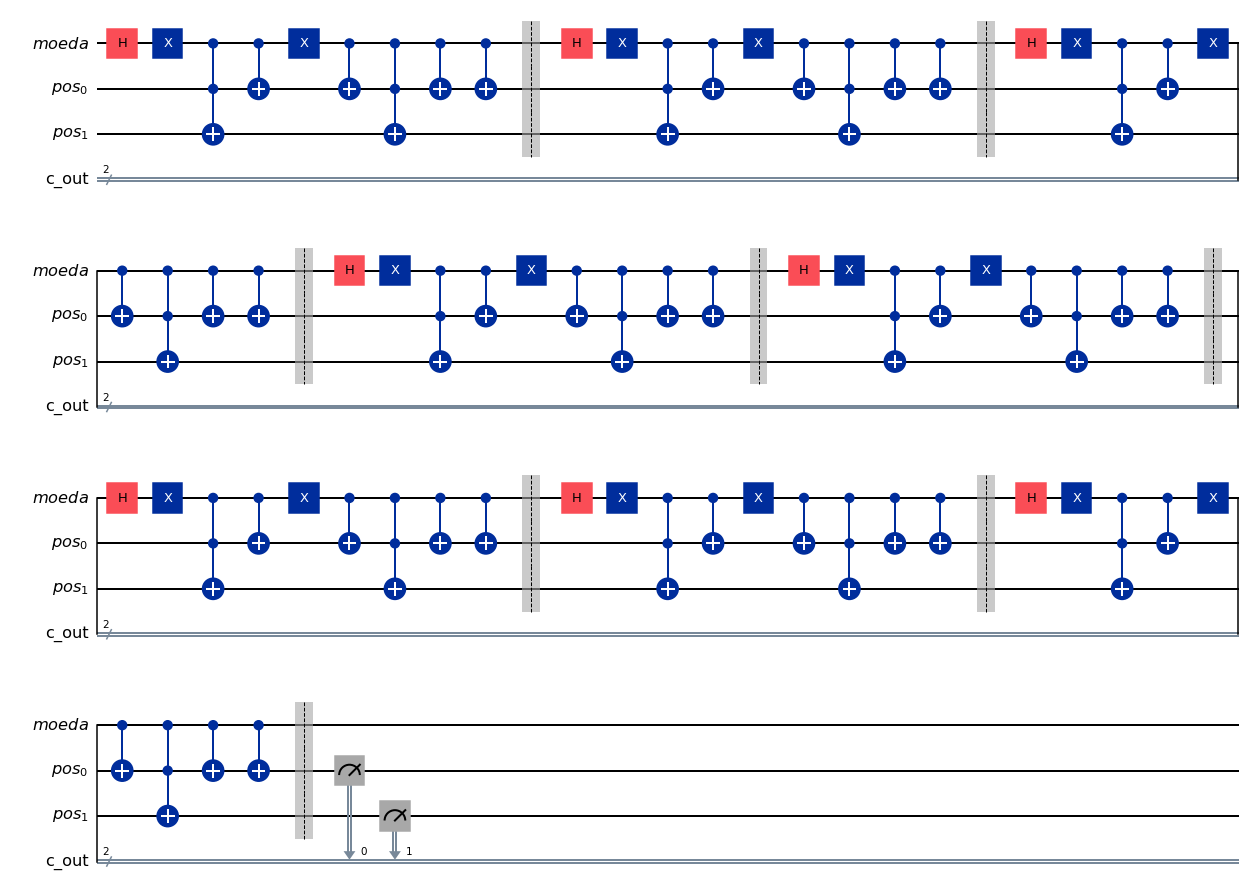

In [44]:
def create_quantum_walk_circuit(n_steps):
    q_coin = QuantumRegister(1, name='moeda')      # Qubit 0
    q_pos = QuantumRegister(2, name='pos')         # Qubits 1 y 2
    c_reg = ClassicalRegister(2, name='c_out')     # medição da posição
    
    qc = QuantumCircuit(q_coin, q_pos, c_reg)
    
    
    for step in range(n_steps):
        # 1. 
        qc.h(q_coin) 
        
        # 2. Operador de Deslocamento (S)
        # Lógica: Incrementa se moeda=0, decrementa se moeda=1
        # PARA INCREMENTAR (|0> -> +1) <<<<
        # Invertemos a moeda para ativar os controles com '0'
        
        qc.x(q_coin)
        
        # Incremento en 2 qubits (q_pos[0] es LSB, q_pos[1] es MSB)
        # Sumar 1 a 2 qubits: CCX (carry) luego CX (suma)
        qc.ccx(q_coin, q_pos[0], q_pos[1]) # Carry ao bit de acima
        qc.cx(q_coin, q_pos[0])            # Soma ao bit baixo
        
        # Restauramos a moeda ao seu estado original.
        qc.x(q_coin)
        
       # >>>> CONDICIONAL PARA DECREMENTO (|1> -> -1) <<<<
       # Subtrair 1 é equivalente a adicionar 3 (11 em binário) módulo 4,
       # ou inverter bits -> adicionar 1 -> inverter bits.
       # Aqui usamos lógica de subtração direta controlada por q_coin (que agora é 1).

       # Decremento em 2 qubits:
       # Se q_pos[0] for 0, q_pos[1] deve ser alterado (emprestado).

       # Portanto, q_pos[0] está sempre em silêncio.
        
        # Implementação da resta controlada:
        qc.cx(q_coin, q_pos[0])            
        qc.ccx(q_coin, q_pos[0], q_pos[1]) 
        qc.cx(q_coin, q_pos[0])            
        qc.cx(q_coin, q_pos[0])           
        
        qc.barrier() 

    # --- Medição ---
    # Só medimos os qubits da posição
    qc.measure(q_pos, c_reg)
    
    return qc


n_steps = 8 # Número de passos 
qc = create_quantum_walk_circuit(n_steps)

# Circuito
qc.draw('mpl')

In [45]:
#from qiskit.quantum_info import Statevector
#psi = Statevector(qc)
#psi.draw(output = "latex")

## Simulação

In [46]:
from qiskit_aer.aerprovider import AerSimulator

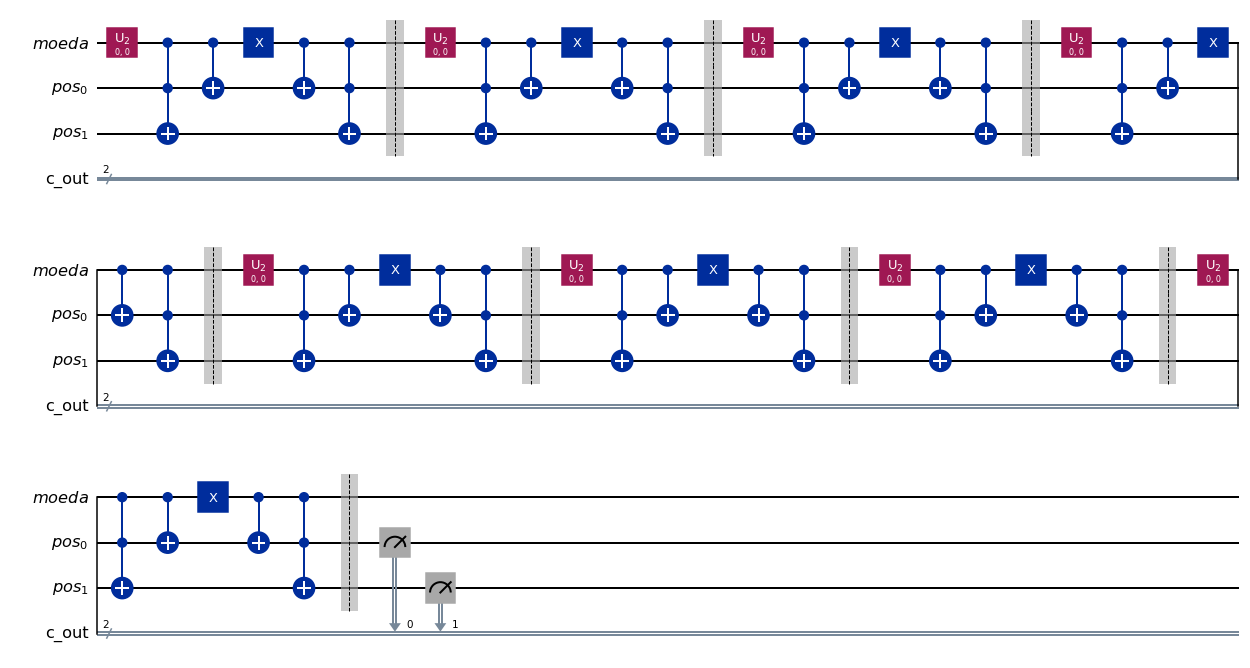

In [47]:
# Escolher simulador
simulator = AerSimulator()
circ = transpile(qc, simulator)

circ.draw('mpl')

In [48]:
# Rodar e obter resultados
result = simulator.run(qc, shots = 4000).result()
counts = result.get_counts(qc)
print(counts)

{'00': 4000}


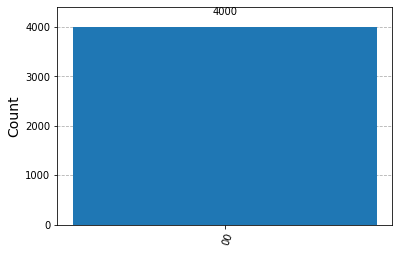

In [49]:
plot_histogram(counts)

In [30]:
def counting_to_probability(contagem):
    m = sum(list(contagem.values()))
    n = len(list(contagem.keys())[0])
    L = [bin(i)[2:] for i in range(2**n)]
    L = list(map(lambda x: '0'*(n-len(x))+x,L))
    return {j:contagem[j]/m for j in contagem.keys()}

In [50]:
probs = counting_to_probability(counts)
print(probs)

{'00': 1.0}


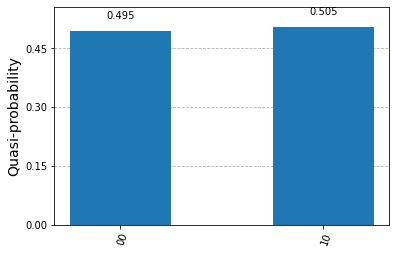

In [43]:
plot_histogram(probs)